Cleaning the data. First we remove outliers 

Raw EEG contains:

1. Low-frequency drift
	•	electrode movement
	•	sweating
	•	baseline shifts

2. High-frequency noise
	•	muscle activity (EMG)
	•	device noise

3. Powerline interference
	•	60 Hz (US)

What we actually want

Brain activity lives roughly in:

Band | Range | Meaning

Delta 0.5–4 Hz - deep sleep

Theta 4–8 Hz drowsy

Alpha 8–13 Hz relaxed

Beta 13–30 Hz active thinking

Gamma 30–40+ Hz high activity


Seizures often show:
	•	abnormal synchronization
	•	often in 3–25 Hz range


Do NOT:
	•	filter multiple times
	•	normalize before filtering



Extracting EDF parameters from data/raw/chb01/chb01_01.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 921599  =      0.000 ...  3599.996 secs...
Basic Info:
<RawEDF | chb01_01.edf, 23 x 921600 (3600.0 s), ~161.7 MiB, data loaded>

Detailed Info:
<Info | 8 non-empty values
 bads: []
 ch_names: FP1-F7, F7-T7, T7-P7, P7-O1, FP1-F3, F3-C3, C3-P3, P3-O1, ...
 chs: 23 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: 2076-11-06 11:42:54 UTC
 nchan: 23
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | his_id: Surrogate>
>
Using matplotlib as 2D backend.


/var/folders/8g/ttg2t0td2blcgq4cm80ph_b80000gn/T/ipykernel_27304/3035262045.py:7: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file_path, preload=True)


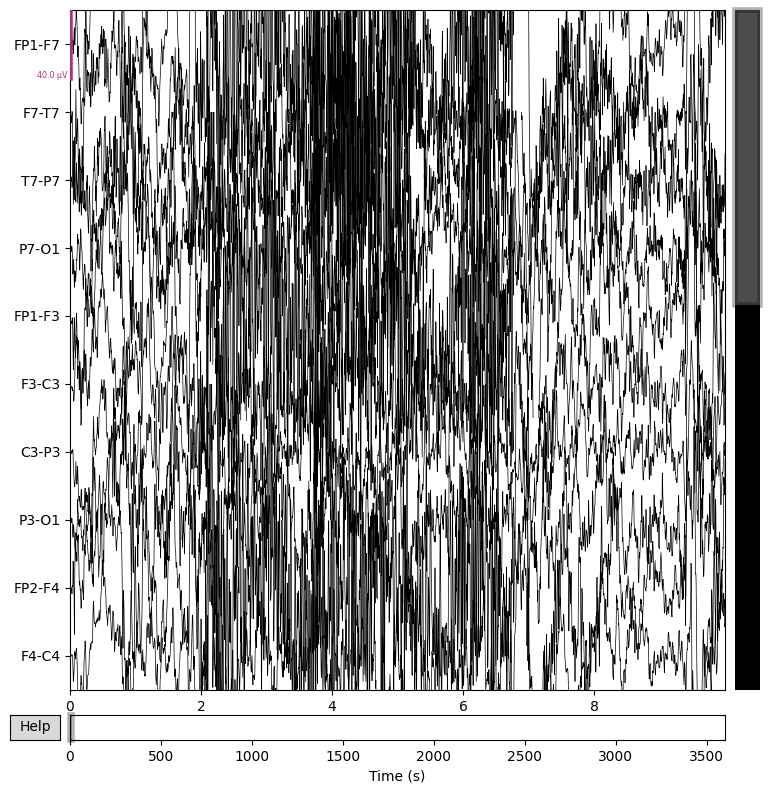

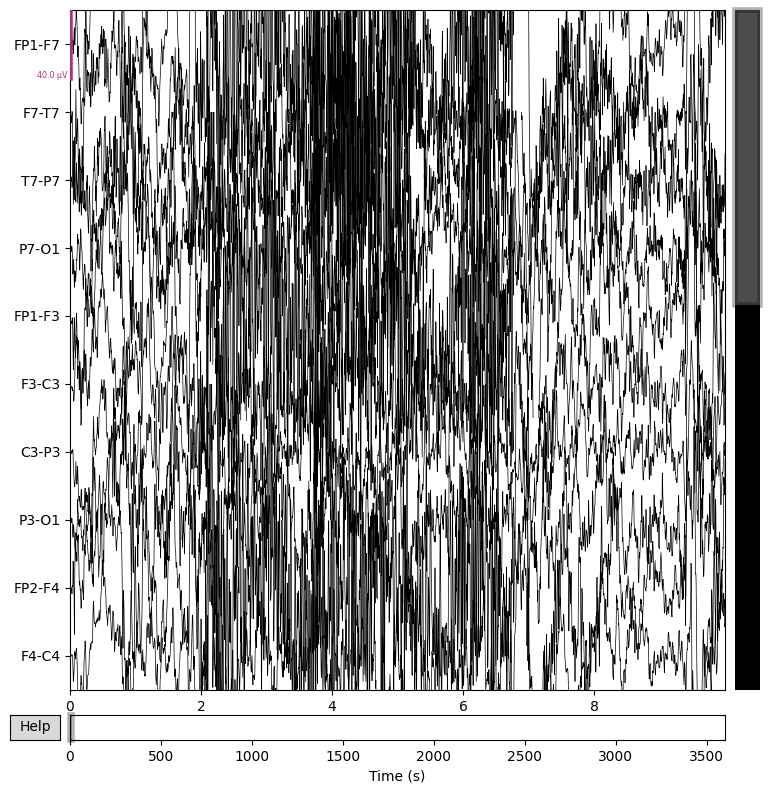

In [1]:
import matplotlib as mt
import mne
import numpy as np

file_path = "data/raw/chb01/chb01_01.edf"

raw = mne.io.read_raw_edf(file_path, preload=True)

print("Basic Info:")
print(raw)

print("\nDetailed Info:")
print(raw.info)

raw.plot(duration=10, n_channels=10)

In [2]:
raw.filter(l_freq=0.5, h_freq=40)
raw.notch_filter(freqs=60)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1691 samples (6.605 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband e

<RawEDF | chb01_01.edf, 23 x 921600 (3600.0 s), ~161.7 MiB, data loaded>

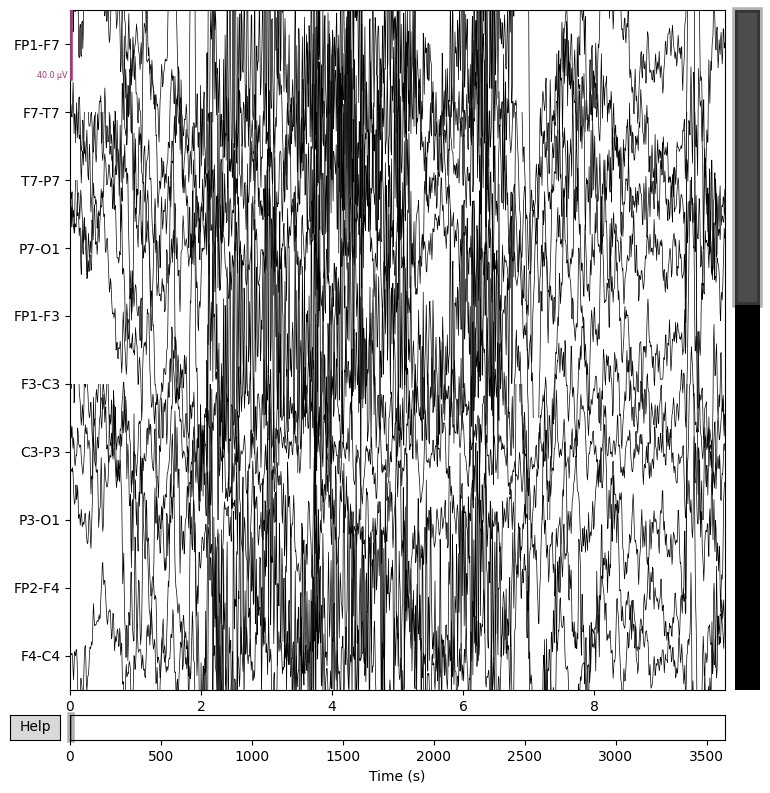

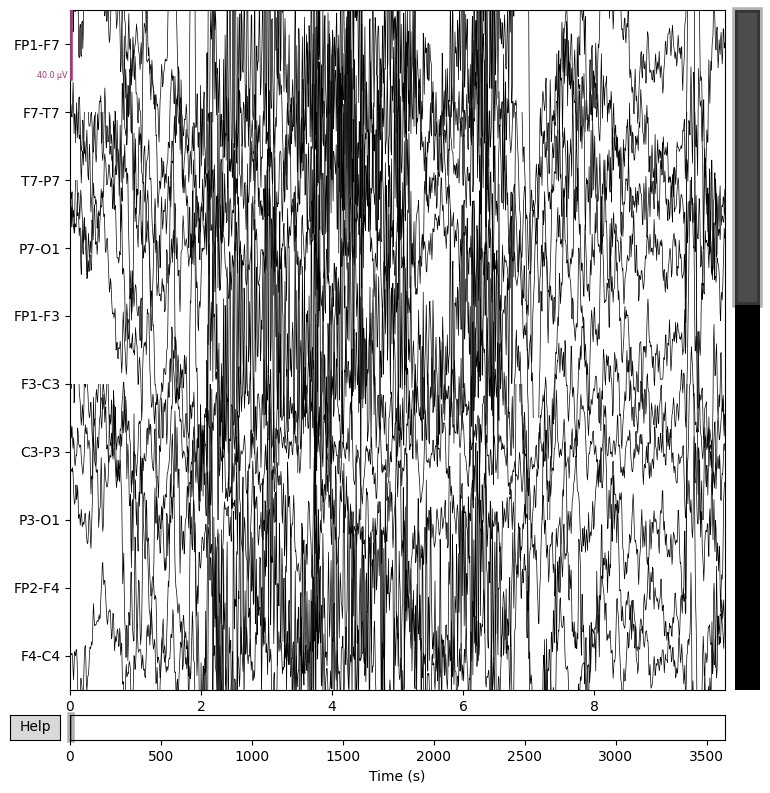

In [3]:
raw.plot(duration=10, n_channels=10)

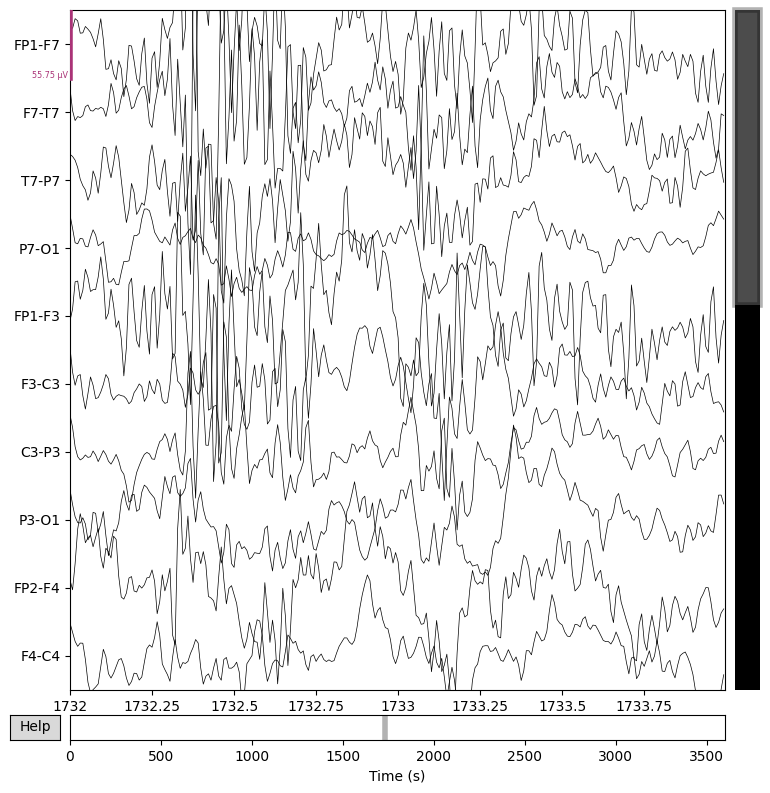

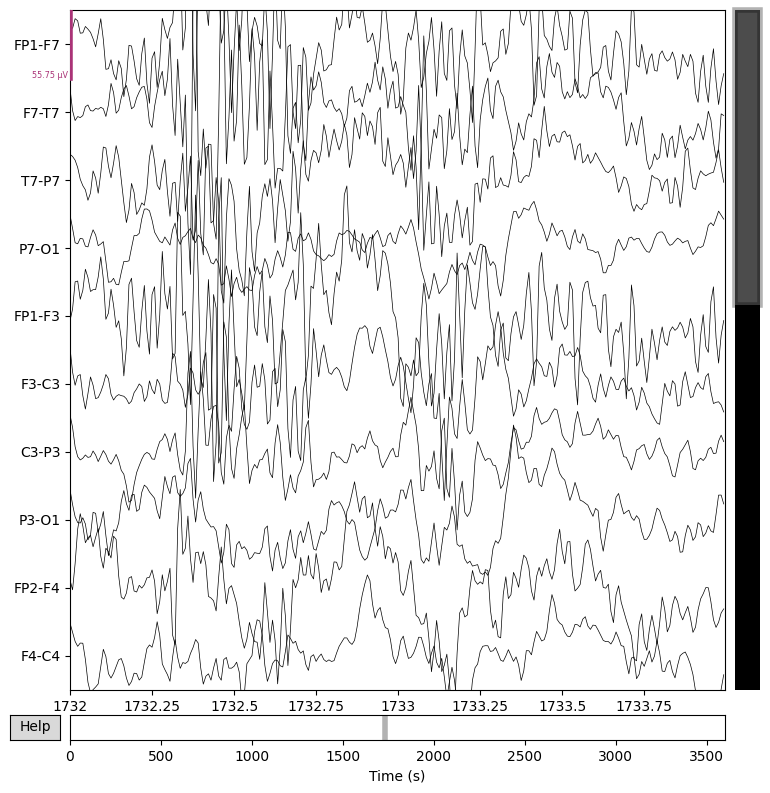

In [4]:
raw.plot(
    start=1732,# - 10,
    duration=2,
    n_channels=10,
    scalings='auto'
)

Why 55.7 µV in the zoomed seizure area and 40 µV in the zoomed-out view?

Because raw.plot() is still auto-scaling per window.

So:
	•	zoomed seizure view: MNE sees larger local excursions and sets a bigger display scale, like 55.7 µV
	•	zoomed-out view: MNE compresses more data into the screen and may use 40 µV

That number is basically a display scale reference, not “the whole file’s true max amplitude.”

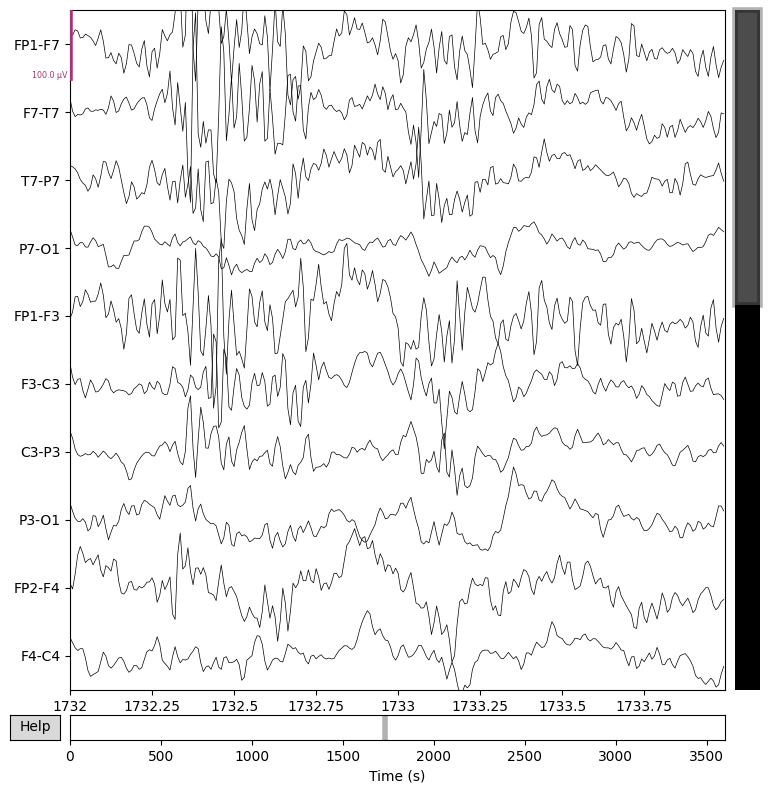

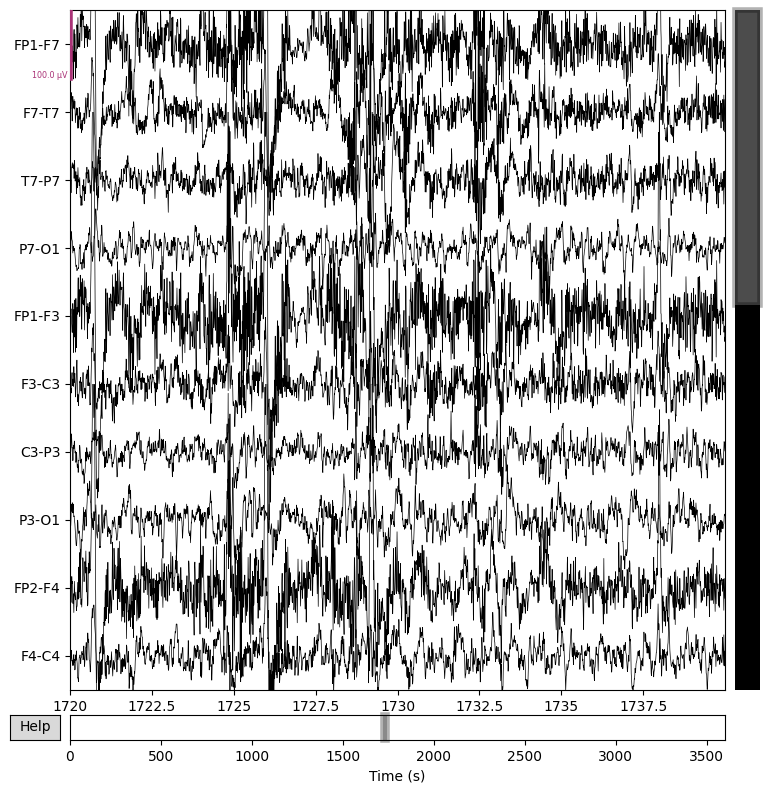

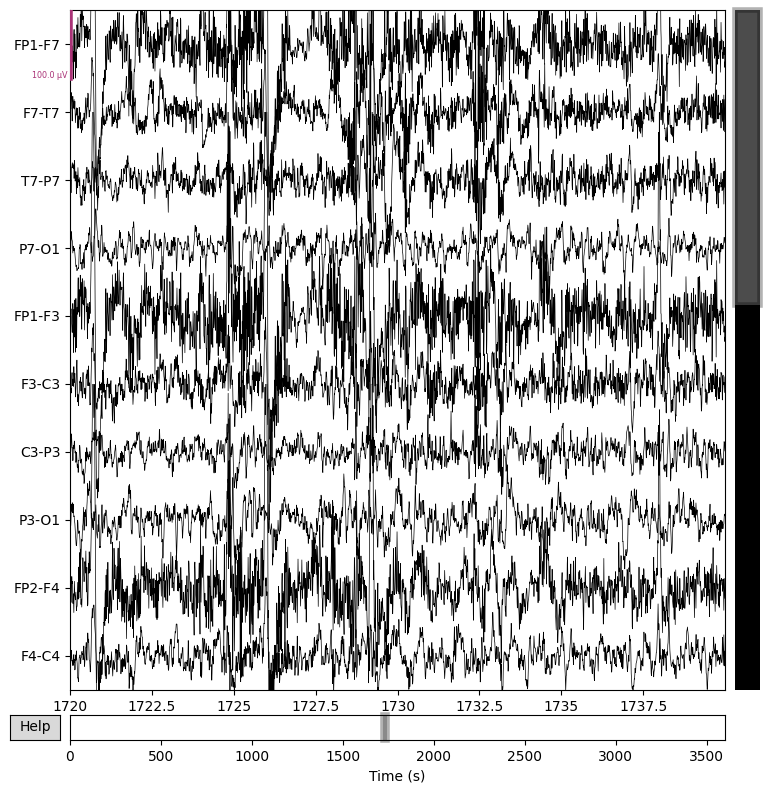

In [5]:
raw.plot(start=1732, duration=2, n_channels=10, scalings=dict(eeg=50e-6))
raw.plot(start=1720, duration=20, n_channels=10, scalings=dict(eeg=50e-6))

In [6]:
import numpy as np

data, times = raw.get_data(return_times=True)
sfreq = raw.info["sfreq"]

# seizure region
s1 = int(1732 * sfreq)
e1 = int(1734 * sfreq)
seizure_seg = data[:, s1:e1]

# non-seizure region
s2 = int(1000 * sfreq)
e2 = int(1002 * sfreq)
normal_seg = data[:, s2:e2]

print("Seizure region min/max (uV):",
      seizure_seg.min() * 1e6, seizure_seg.max() * 1e6)

print("Normal region min/max (uV):",
      normal_seg.min() * 1e6, normal_seg.max() * 1e6)

Seizure region min/max (uV): -163.23989791007207 197.3516678076828
Normal region min/max (uV): -239.436103786982 171.54946624326593


Min/max is very sensitive to even one extreme point.

For example, a normal window may have:
	•	one large transient dip to -239 µV

and that alone makes the range look huge, even if the rest of the window is not seizure-like.

So min/max is a crude statistic.

Better things to inspect after loading and filtering

Instead of only min/max, look at:

1. Standard deviation

This tells you typical spread, not just one extreme.

In [7]:
import numpy as np

print("Seizure std (uV):", np.std(seizure_seg) * 1e6)
print("Normal std (uV):", np.std(normal_seg) * 1e6)

Seizure std (uV): 26.32274428018381
Normal std (uV): 34.21506839090943


In [8]:
print("Seizure RMS (uV):", np.sqrt(np.mean(seizure_seg**2)) * 1e6)
print("Normal RMS (uV):", np.sqrt(np.mean(normal_seg**2)) * 1e6)

Seizure RMS (uV): 26.32277131555992
Normal RMS (uV): 34.44581479758048


Filtering — What we did and what we learned

⸻

1. EEG raw signal contains multiple noise sources

Raw EEG is not just brain activity; it includes drift, muscle noise, and electrical interference.
So the signal you load is a mixture of useful neural activity and unwanted artifacts.

⸻

2. Brain-relevant frequencies are limited

Most meaningful EEG activity lies roughly between 0.5 Hz and 40 Hz.
Anything outside this range is usually noise or not useful for seizure detection.

⸻

3. Bandpass filtering isolates useful signal

We applied a bandpass filter:
0.5 Hz → 40 Hz
This removes slow drift (below 0.5 Hz) and high-frequency noise (above 40 Hz), keeping only relevant brain activity.

⸻

4. Notch filtering removes powerline interference

Electrical systems introduce a strong 60 Hz noise in the US.
We applied a notch filter at 60 Hz to specifically remove this narrow-band interference.

⸻

5. Filtering changes signal shape (not just noise removal)

Filtering smooths the signal and removes extreme fluctuations outside the band.
So amplitude and waveform appearance can change, but the meaningful structure becomes clearer.

⸻

6. Filtering is a design choice, not a fixed rule

Choosing 0.5–40 Hz defines what information you keep or discard.
If you change this range, you may lose important seizure characteristics or keep unwanted noise.

⸻

7. Visualization after filtering must be interpreted carefully

MNE plots auto-scale the y-axis depending on the window you view.
So differences like “40 µV vs 55 µV” are often display effects, not true signal changes.

⸻

8. Amplitude alone is not a seizure indicator

After filtering, seizure segments did not necessarily show higher min/max or std.
This confirms seizures are better identified by patterns and frequency content, not just magnitude.

⸻

9. Filtering must happen before normalization and windowing

If you normalize first, noise gets preserved and scaled incorrectly.
Correct order is:
LOAD → INSPECT → FILTER → NORMALIZE → WINDOW


⸻

10. Filtering quality must always be verified visually

After filtering, we checked plots to confirm the signal is smoother and structured.
This step ensures no incorrect filtering parameters were applied.

Always remember that Filetring isnt just cleaning noice. It is like defining the signal spce the model we train will learn from.